In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load cleaned dataset
df=pd.read_csv('inbound_clean.csv')
df.head()

,reporter_area_label,year,business_arrivals,personal_arrivals,tourists,total_arrivals,air_arrivals,expenditure,acc_establishments,acc_capacity,ALOS,exp_per_arrival,acc_guests,acc_overnights
0,Albania,2019,101200.0,6304800.0,6128000.0,6406000.0,783900.0,2.458000e+09,1126.0,111772.0,2.580000,383.702779,736000.0,1987000.0
1,Albania,2020,115300.0,2542500.0,2604000.0,2658000.0,269800.0,1.242856e+09,1237.0,117147.0,2.344786,467.590531,280514.0,748363.0
2,Albania,2021,100200.0,5588400.0,5515000.0,5689000.0,764700.0,2.479951e+09,1256.0,121205.0,2.564628,435.920293,656500.0,1932096.0
3,Albania,2022,106300.0,7437500.0,7104700.0,7543800.0,1250000.0,3.255061e+09,1385.0,139450.0,2.413045,431.488289,846359.0,2358400.0
4,Algeria,2019,158100.0,1775700.0,NaN,2371000.0,NaN,1.400000e+08,1417.0,NaN,1.680000,59.046816,851000.0,1401000.0


In [3]:
#rename reporter area label column to country
df.rename(columns={'reporter_area_label': 'country'}, inplace=True)

In [4]:
#define latest year
latest_year = df[df['year'] == 2024].copy()

#pareto analysis to check concentration of arrivals
latest_year = latest_year.sort_values('total_arrivals', ascending=False)
latest_year['cumulative_arrivals'] = latest_year['total_arrivals'].cumsum()
total_arrivals = latest_year['total_arrivals'].sum()
latest_year['arrival_pct'] = (latest_year['cumulative_arrivals'] / total_arrivals) * 100

#number of top 20% of countries with highest inbound arrivals
top_20_count = int(len(latest_year) * 0.2)
top_20_arrival_share = latest_year.iloc[:top_20_count]['arrival_pct'].iloc[-1]

# recovery winner volume
#define recovery winners as those > 100% of 2019 levels
pivot_arr = df.pivot(index='country', columns='year', values='total_arrivals')
recovery_winners = pivot_arr[pivot_arr[2024] > pivot_arr[2019]].index.tolist()

winners_2024_vol = latest_year[latest_year['country'].isin(recovery_winners)]['total_arrivals'].sum()
winners_share = (winners_2024_vol / total_arrivals) * 100

print(f"Total Countries: {len(latest_year)}")
print(f"Share of arrivals in top 20% of countries: {top_20_arrival_share:.2f}%")
print(f"Share of total arrivals coming from 'Recovery Winners': {winners_share:.2f}%")


Total Countries: 41
Share of arrivals in top 20% of countries: 76.34%
Share of total arrivals coming from 'Recovery Winners': 37.47%


<Axes: xlabel='exp_per_arrival', ylabel='Count'>

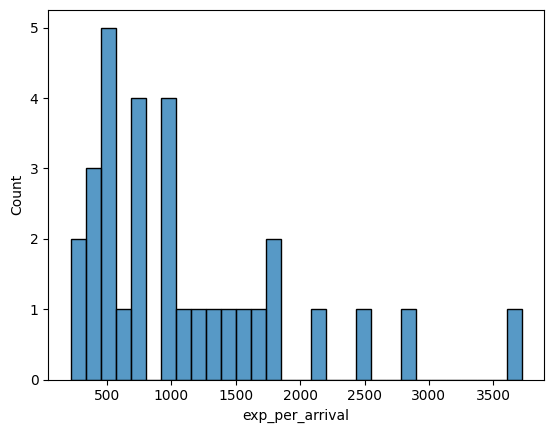

In [5]:
#distribution of expenditure per arrival
df_latest = df[df['year'] == 2024].copy()
sns.histplot(df_latest['exp_per_arrival'].dropna(), bins=30)

In [6]:
#Which destinations have the highest ratio of Expenditure to Arrivals, and how does this correlate with Accommodation Capacity?
#filter to latest year
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year].copy()

#expernditure per arrival column already exists
#so pull top 10 df_latest records sorted in descending order by expenditure per arrival
top10 = df_latest.nlargest(10, 'exp_per_arrival')
top10 = top10[['country', 'exp_per_arrival']]
print(f'Top 10 Countries with Highest Expenditure to Arrival Ratio: \n {top10}')

Top 10 Countries with Highest Expenditure to Arrival Ratio: 
                                                country  exp_per_arrival
268                                              India      3719.765677
27                                 Antigua and Barbuda      2842.637494
277                                             Israel      2535.728953
558  United Kingdom of Great Britain and Northern I...      2166.130486
342                                              Malta      1799.780432
152                                         Costa Rica      1743.839796
122                                             Canada      1673.017387
532                                Trinidad and Tobago      1554.443589
98                              Bosnia and Herzegovina      1457.138084
480                                       Saudi Arabia      1384.098679


In [7]:
#handle accommodation capacity
#to make it comparable across countries of different size, we'll compute accommodation per 1000 arrivals
df_latest['capacity_per_1000_arrivals']= round((df_latest['acc_capacity'])/((df_latest['total_arrivals']/1000)), 2)

df_latest.head()

,country,year,business_arrivals,personal_arrivals,tourists,total_arrivals,air_arrivals,expenditure,acc_establishments,acc_capacity,ALOS,exp_per_arrival,acc_guests,acc_overnights,capacity_per_1000_arrivals
13,Andorra,2024,109000.0,9537700.0,4167600.0,9646700.0,NaN,NaN,219.0,41709.0,2.770000,NaN,3.175722e+06,8.798327e+06,4.32
27,Antigua and Barbuda,2024,15000.0,315000.0,330200.0,371200.0,330000.0,1.055187e+09,NaN,NaN,NaN,2842.637494,2.734640e+05,NaN,NaN
33,Argentina,2024,352000.0,2408000.0,6603877.0,11358793.0,2826992.0,5.385095e+09,15899.0,991908.0,2.429040,474.090420,4.172000e+06,9.855000e+06,87.33
54,Bahamas,2024,63248.0,1805868.0,1869133.0,11232029.0,1707130.0,5.543218e+09,282.0,48291.0,5.340000,493.518823,1.472505e+06,7.868468e+06,4.30
60,Bahrain,2024,367000.0,6250000.0,6618000.0,14882000.0,NaN,4.227000e+09,249.0,51241.0,2.423757,284.034404,5.158509e+06,1.251578e+07,3.44


In [8]:
#identify the "high-yield, low-Infrastructure" (high-friction) markets
#these are the markets where travelers spend a lot but accommodation is scarce relative to volume.
df_latest = df_latest.dropna(subset=['exp_per_arrival', 'capacity_per_1000_arrivals'])

#label top 10 high yield countries sorted by expenditure per arrival
top10 = df_latest.nlargest(10, 'exp_per_arrival')
top10 = top10[['country', 'exp_per_arrival', 'capacity_per_1000_arrivals']]
top10

,country,exp_per_arrival,capacity_per_1000_arrivals
277,Israel,2535.728953,225.95
342,Malta,1799.780432,20.70
98,Bosnia and Herzegovina,1457.138084,44.07
480,Saudi Arabia,1384.098679,46.19
213,Finland,1225.036861,52.65
76,Belgium,1084.393777,22.06
198,El Salvador,991.266219,5.03
166,Cyprus,966.816376,34.45
508,Spain,774.894289,31.27
494,Slovenia,726.675686,17.54


Statistical Findings (2024)
Correlation between Expenditure Ratio and Capacity: 0.69


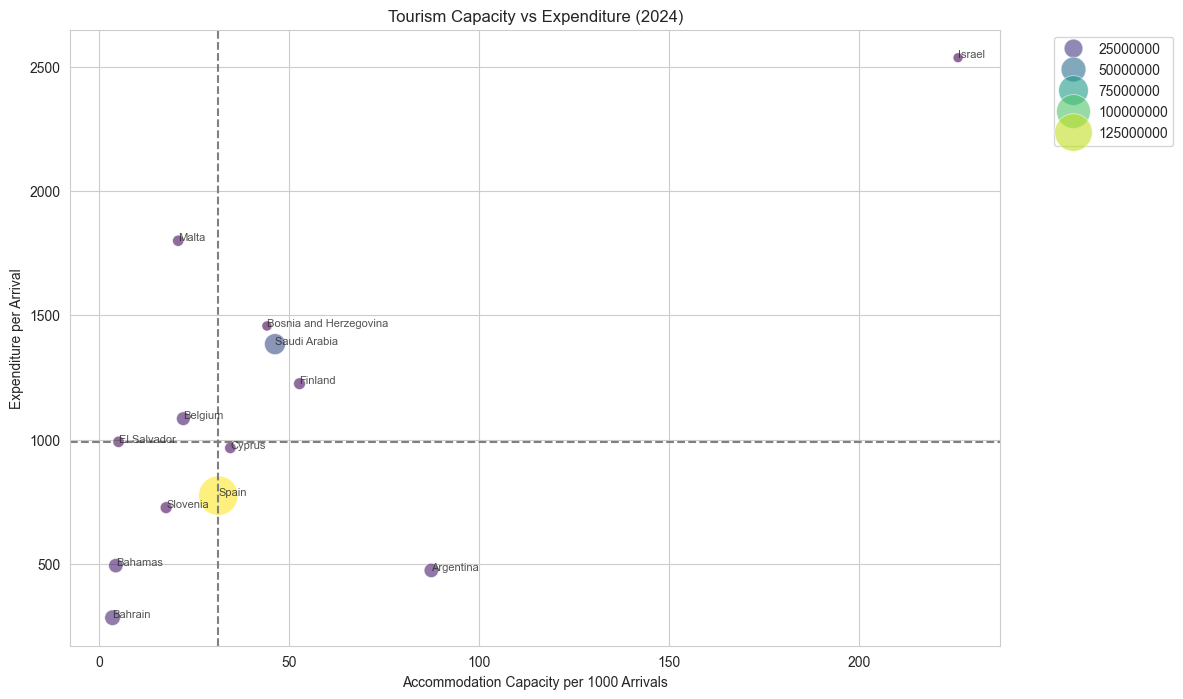

In [9]:
#calculate correllation
correlation = df_latest['exp_per_arrival'].corr(df_latest['capacity_per_1000_arrivals'])

print(f'Statistical Findings ({latest_year})')
print(f'Correlation between Expenditure Ratio and Capacity: {correlation:.2f}')

#visualize relationship between expenditure per arrival and accommodation capacity
df_plot = df_latest.dropna(subset=[
    'exp_per_arrival',
    'capacity_per_1000_arrivals',
    'total_arrivals'
])

plt.figure(figsize=(12,8))
sns.set_style('whitegrid')

# scatter (bubble plot)
sns.scatterplot(
    data=df_plot,
    x='capacity_per_1000_arrivals',
    y='exp_per_arrival',
    size='total_arrivals',
    hue='total_arrivals',
    sizes=(50, 800),
    alpha=0.6,
    palette='viridis'
)

# ---- quadrant lines (median split) ----
x_median = df_plot['capacity_per_1000_arrivals'].median()
y_median = df_plot['exp_per_arrival'].median()

plt.axvline(x_median, linestyle='--', color='grey')
plt.axhline(y_median, linestyle='--', color='grey')

# ---- country labels ----
for i in range(len(df_plot)):
    plt.text(
        df_plot['capacity_per_1000_arrivals'].iloc[i],
        df_plot['exp_per_arrival'].iloc[i],
        df_plot['country'].iloc[i],
        fontsize=8,
        alpha=0.8
    )

plt.title(f'Tourism Capacity vs Expenditure ({latest_year})')
plt.xlabel('Accommodation Capacity per 1000 Arrivals')
plt.ylabel('Expenditure per Arrival')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [10]:
#Which regions have surpassed 2019 arrival levels the fastest, and is their tourism spending growing faster than their arrival volume?
#filter 2019 and 2024 data
recovery_df = df[df['year'].isin([2019, 2024])].copy()

#drop records with missing arrivals or expenditure data
recovery_df= recovery_df.dropna(subset=['total_arrivals', 'expenditure'])

recovery_df=recovery_df[['country', 'year', 'total_arrivals', 'expenditure']]
recovery_df.head()

,country,year,total_arrivals,expenditure
0,Albania,2019,6406000.0,2.458000e+09
4,Algeria,2019,2371000.0,1.400000e+08
8,Andorra,2019,8235000.0,1.910000e+09
14,Angola,2019,217500.0,3.950000e+08
18,Anguilla,2019,166000.0,1.770000e+08


In [11]:
#calculate arrivals and expenditure growth rates in 2024 vs. 2019
arr_pivot = recovery_df.groupby(['country', 'year'])['total_arrivals'].mean().unstack()
exp_pivot = recovery_df.groupby(['country', 'year'])['expenditure'].mean().unstack()

recovery = pd.DataFrame(index=arr_pivot.index)
if 2019 in arr_pivot.columns and 2024 in arr_pivot.columns:
    recovery['Arrival_Growth'] = round((arr_pivot[2024] / arr_pivot[2019] - 1) * 100, 2)
    recovery['Expenditure_Growth'] = round((exp_pivot[2024] / exp_pivot[2019] - 1) * 100, 2)
    recovery['Value_Premium'] = round((recovery['Expenditure_Growth'] - recovery['Arrival_Growth']), 2)
    
    #identify countries with highest arrival growth rates
    top_recovery = recovery[recovery['Arrival_Growth'] > 0].sort_values('Arrival_Growth', ascending=False)
    
    print("Post-Pandemic Recovery Analysis (2024 vs 2019)")
    print(top_recovery)
else:
    print("Data for 2019 or 2024 is missing from the selection.")

Post-Pandemic Recovery Analysis (2024 vs 2019)
                        Arrival_Growth  Expenditure_Growth  Value_Premium
country                                                                  
Saudi Arabia                     64.99              133.45          68.46
Bahamas                          54.92               33.57         -21.35
El Salvador                      49.94              135.71          85.77
Bahrain                          34.54                9.51         -25.03
Bosnia and Herzegovina           15.92               65.19          49.27
Mongolia                         14.13               21.82           7.69
Slovenia                          7.49                9.53           2.04
Belgium                           3.15               -0.61          -3.76
Argentina                         2.05               -4.76          -6.81
Trinidad and Tobago               0.93               57.06          56.13


In [12]:
#define premium markets
#these are markets where expenditure grew faster than arrival volume
premium_markets = recovery.dropna().copy()

premium_markets = premium_markets[premium_markets['Expenditure_Growth'] > premium_markets['Arrival_Growth']]

print(len(premium_markets))
premium_markets.sort_values('Value_Premium', ascending=False)

17


,Arrival_Growth,Expenditure_Growth,Value_Premium
country,,,
El Salvador,49.94,135.71,85.77
Antigua and Barbuda,-64.14,6.16,70.30
Saudi Arabia,64.99,133.45,68.46
India,-44.45,16.92,61.37
Trinidad and Tobago,0.93,57.06,56.13
Georgia,-16.44,37.52,53.96
Bosnia and Herzegovina,15.92,65.19,49.27
Mexico,-11.29,33.60,44.89
Costa Rica,-4.67,29.44,34.11


In [13]:
#in markets with high 'inbound arrivals by mode of transport - air', what is the average length of stay?
#retrieve data of countries with air arrivals in latest year
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year].copy()
air_arrival_markets = df_latest.dropna(subset=['air_arrivals'])

#we already have average length of stay data (ALOS)
#so we'll just pull the data
#define high'inbound arrivals by mode of transport - air' markets as those in the top 25th percentile
threshold= air_arrival_markets['air_arrivals'].quantile(0.75)
#identify high 'inbound arrivals by mode of transport - air' markets
high_air = air_arrival_markets[air_arrival_markets['air_arrivals'] >= threshold].sort_values('ALOS', ascending=False)
print(f"High air-arrivals markets: \n {pd.DataFrame(high_air[['country', 'air_arrivals', 'ALOS']])}")

High air-arrivals markets: 
                                                country  air_arrivals      ALOS
187                                 Dominican Republic  8.535701e+06  8.010000
480                                       Saudi Arabia  1.911969e+07  7.686109
358                                             Mexico  2.316526e+07  3.750000
508                                              Spain  7.711979e+07  3.270102
283                                              Italy  3.858700e+07  3.103102
122                                             Canada  1.026900e+07  2.116129
268                                              India  8.214000e+06       NaN
558  United Kingdom of Great Britain and Northern I...  3.190068e+07       NaN


In [14]:
#correllation between air arrivals and average length of stay
corr = df_latest['air_arrivals'].corr(df_latest['ALOS'])
print(f"\n**Correlation between Air Arrival Volume and Stay Duration:** {corr:.2f}")


**Correlation between Air Arrival Volume and Stay Duration:** -0.18


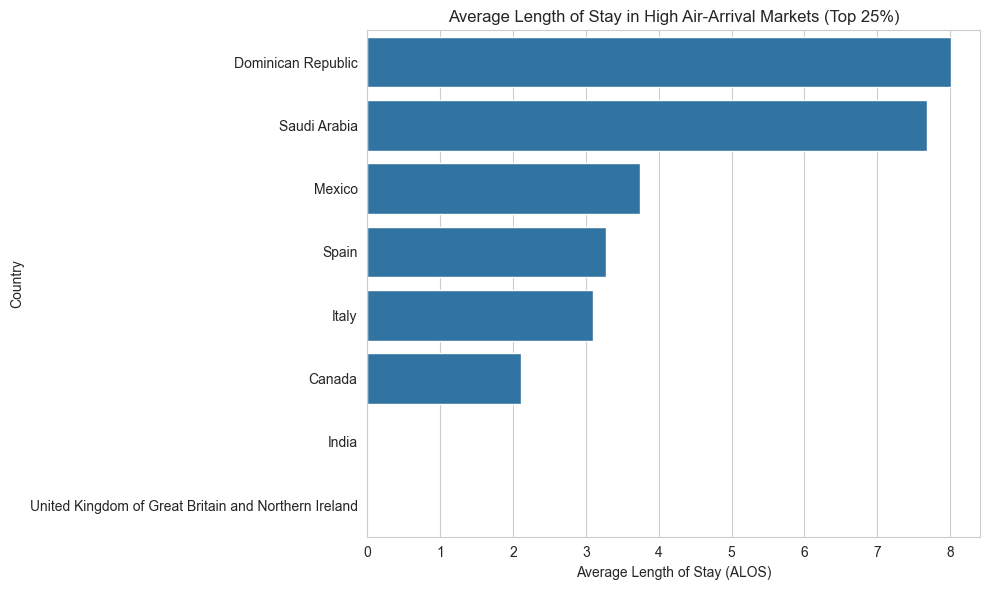

In [15]:
#visualize air arrivals vs. alos
plt.figure(figsize=(10,6))
sns.barplot(data=high_air, x='ALOS', y='country')

plt.title('Average Length of Stay in High Air-Arrival Markets (Top 25%)')
plt.xlabel('Average Length of Stay (ALOS)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [16]:
#How does the main purpose of the trip correlate with the average tourism expenditure in top-performing countries?
#data for latest year already exists
#percentages of business and leisure arrivals relative to total trips
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year].copy()
#calculate ratios
df_latest['business'] = round(((df_latest['business_arrivals']/df_latest['total_arrivals'])*100), 2)
df_latest['leisure'] = round(((df_latest['personal_arrivals']/df_latest['total_arrivals'])*100), 2)

df_latest.head()

,country,year,business_arrivals,personal_arrivals,tourists,total_arrivals,air_arrivals,expenditure,acc_establishments,acc_capacity,ALOS,exp_per_arrival,acc_guests,acc_overnights,business,leisure
13,Andorra,2024,109000.0,9537700.0,4167600.0,9646700.0,NaN,NaN,219.0,41709.0,2.770000,NaN,3.175722e+06,8.798327e+06,1.13,98.87
27,Antigua and Barbuda,2024,15000.0,315000.0,330200.0,371200.0,330000.0,1.055187e+09,NaN,NaN,NaN,2842.637494,2.734640e+05,NaN,4.04,84.86
33,Argentina,2024,352000.0,2408000.0,6603877.0,11358793.0,2826992.0,5.385095e+09,15899.0,991908.0,2.429040,474.090420,4.172000e+06,9.855000e+06,3.10,21.20
54,Bahamas,2024,63248.0,1805868.0,1869133.0,11232029.0,1707130.0,5.543218e+09,282.0,48291.0,5.340000,493.518823,1.472505e+06,7.868468e+06,0.56,16.08
60,Bahrain,2024,367000.0,6250000.0,6618000.0,14882000.0,NaN,4.227000e+09,249.0,51241.0,2.423757,284.034404,5.158509e+06,1.251578e+07,2.47,42.00


In [17]:
#filter for top performing countries
top_vol_threshold = df_latest['total_arrivals'].quantile(0.6)
top_countries = df_latest[df_latest['total_arrivals'] > top_vol_threshold]
top_countries = df_latest.nlargest(15, 'business')

top_countries = top_countries[['country', 'business', 'leisure', 'exp_per_arrival']]
top_countries = top_countries.dropna(subset='exp_per_arrival')
top_countries

,country,business,leisure,exp_per_arrival
122,Canada,39.76,60.24,1673.017387
76,Belgium,30.96,69.04,1084.393777
213,Finland,24.19,66.13,1225.036861
558,United Kingdom of Great Britain and Northern I...,17.75,80.19,2166.130486
323,Lithuania,14.45,32.89,380.480451
283,Italy,12.74,52.66,696.024846
268,India,10.34,88.37,3719.765677
98,Bosnia and Herzegovina,10.08,89.94,1457.138084
428,Paraguay,9.05,38.47,349.243247
277,Israel,8.93,89.84,2535.728953


In [18]:
#calculate correllation between main purpose of trip and expenditure per arrival
corr = df_latest['business'].corr(df_latest['exp_per_arrival'])
print(f"\nCorrelation between Business Trip Share and Expenditure per Arrival: {corr:.2f}")


Correlation between Business Trip Share and Expenditure per Arrival: 0.23


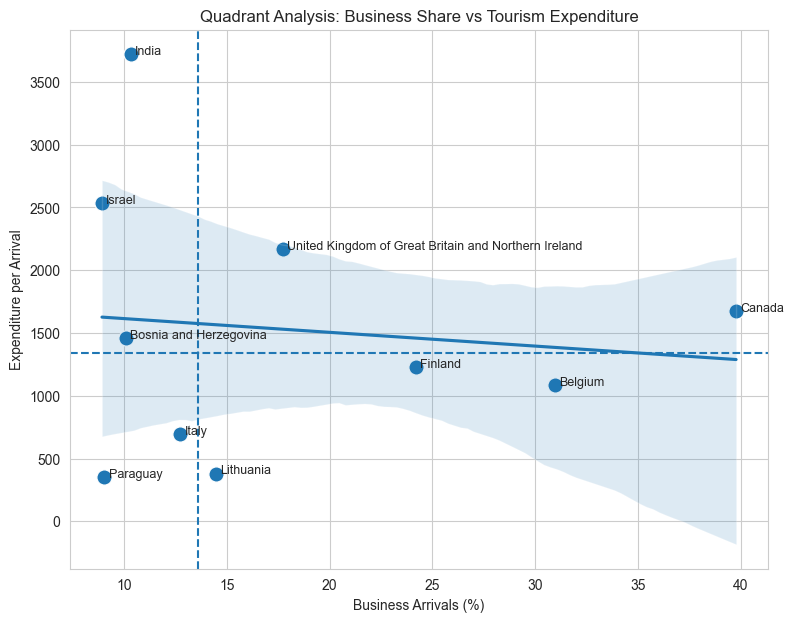

In [19]:
plot_df = top_countries.dropna(subset=['exp_per_arrival', 'business'])

plt.figure(figsize=(9,7))

# scatter
sns.scatterplot(
    data=plot_df,
    x='business',
    y='exp_per_arrival',
    s=120
)

# regression line
sns.regplot(
    data=plot_df,
    x='business',
    y='exp_per_arrival',
    scatter=False
)

# ---- quadrant lines (median split) ----
x_median = plot_df['business'].median()
y_median = plot_df['exp_per_arrival'].median()

plt.axvline(x_median, linestyle='--')
plt.axhline(y_median, linestyle='--')

# ---- labels ----
for i in range(len(plot_df)):
    plt.text(
        plot_df['business'].iloc[i] + 0.2,
        plot_df['exp_per_arrival'].iloc[i],
        plot_df['country'].iloc[i],
        fontsize=9
    )

plt.title('Quadrant Analysis: Business Share vs Tourism Expenditure')
plt.xlabel('Business Arrivals (%)')
plt.ylabel('Expenditure per Arrival')

plt.show()

In [20]:
#what is the variance in monthly/quarterly arrival data across our top 10 primary markets?
#no explicit monthly/quarterly inbound arrivals data available
#so will use variance across the years of interest (last five years of the data i.e. 2020-2024)

#define data window
df_5yr = df[(df['year'] >= 2020) & (df['year'] <= 2024)].copy()

##identify top 10 primary markets by volume
primary_markets = (
    df_5yr.groupby('country')['total_arrivals']
    .sum()
    .nlargest(10)
    .index
    .tolist()
)

primary_markets

['Spain',
 'Mexico',
 'Poland',
 'Italy',
 'United Kingdom of Great Britain and Northern Ireland',
 'Hungary',
 'United States of America',
 'Türkiye',
 'Saudi Arabia',
 'China, Hong Kong Special Administrative Region']

In [21]:
#calculate the coefficient of variation for 2020-2024
#CV = standard deviation/mean
#a higher CV indicates higher volatility
market_cv = (
    df_5yr[df_5yr['country'].isin(primary_markets)]
    .groupby('country')['total_arrivals']
    .agg(['std', 'mean'])
)

market_cv['cv_volatility'] = (market_cv['std'] / market_cv['mean'].replace(0, np.nan)) * 100

market_cv.head()

,std,mean,cv_volatility
country,,,
"China, Hong Kong Special Administrative Region",7.426884e+06,3.925120e+07,18.921419
Hungary,7.470438e+06,3.822383e+07,19.543926
Italy,2.430573e+07,6.530280e+07,37.220038
Mexico,1.438216e+07,6.673084e+07,21.552496
Poland,1.355815e+07,6.569740e+07,20.637275


In [22]:
#calculate linear growth (recovery slope) in primary markets
def calc_slope(x):
    if len(x) > 1:
        return np.polyfit(x['year'], x['total_arrivals'], 1)[0]
    return None

growth_slope = (
    df_5yr[df_5yr['country'].isin(primary_markets)]
    .groupby('country')
    .apply(calc_slope)
)

#merge into market_cv
market_cv['growth_slope'] = growth_slope
#normalize growth slope
market_cv['growth_slope_norm'] = market_cv['growth_slope'] / market_cv['mean']

market_cv

,std,mean,cv_volatility,growth_slope,growth_slope_norm
country,,,,,
"China, Hong Kong Special Administrative Region",7.426884e+06,3.925120e+07,18.921419,1.050320e+07,0.267589
Hungary,7.470438e+06,3.822383e+07,19.543926,7.351000e+06,0.192315
Italy,2.430573e+07,6.530280e+07,37.220038,1.448320e+07,0.221785
Mexico,1.438216e+07,6.673084e+07,21.552496,9.008521e+06,0.134998
Poland,1.355815e+07,6.569740e+07,20.637275,7.829700e+06,0.119178
Saudi Arabia,1.376941e+07,1.812221e+07,75.980865,8.345087e+06,0.460490
Spain,4.502108e+07,9.127991e+07,49.322007,2.765796e+07,0.303002
Türkiye,1.783280e+07,3.246600e+07,54.927613,1.770850e+07,0.545448
United Kingdom of Great Britain and Northern Ireland,1.535779e+07,2.514395e+07,61.079455,8.743608e+06,0.347742


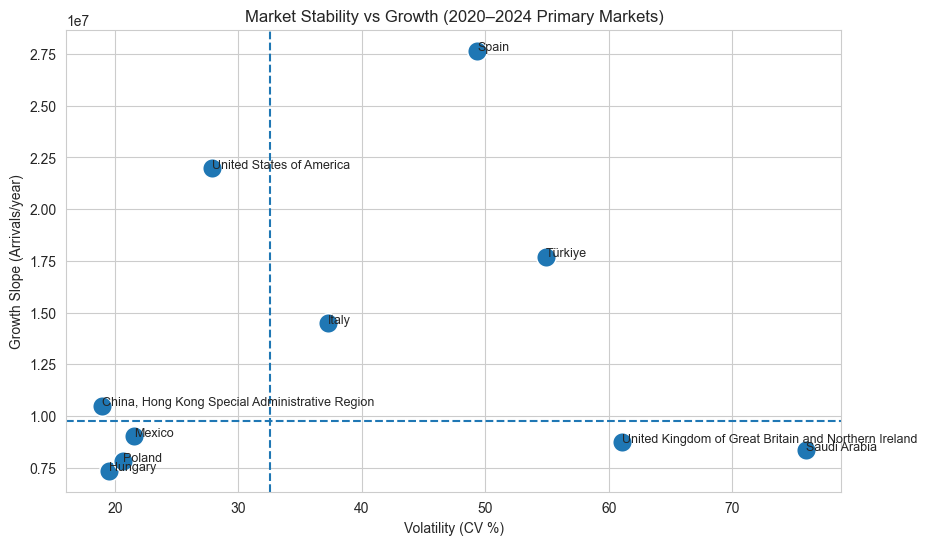

In [23]:
#visuaize linear growth
plot_df = market_cv.reset_index()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x='cv_volatility',
    y='growth_slope',
    s=200
)

# median lines (quadrants)
plt.axvline(plot_df['cv_volatility'].median(), linestyle='--')
plt.axhline(plot_df['growth_slope'].median(), linestyle='--')

for i in range(len(plot_df)):
    plt.text(
        plot_df['cv_volatility'][i],
        plot_df['growth_slope'][i],
        plot_df['country'][i],
        fontsize=9
    )

plt.title('Market Stability vs Growth (2020–2024 Primary Markets)')
plt.xlabel('Volatility (CV %)')
plt.ylabel('Growth Slope (Arrivals/year)')
plt.show()